In [1]:
pip install faker


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 24.5 MB/s eta 0:00:00


In [5]:
import pandas as pd
import random
from faker import Faker
import matplotlib.pyplot as plt

In [6]:
fake=Faker()

In [12]:
num_records = 100

diseases = ["Diabetes", "Hypertension", "Heart Disease", "Fever", "Asthma"]
genders = ["Male", "Female"]

data = []

for i in range(num_records):
    patient = {
        "Patient_ID": f"P{i+1:03}",
        "Name": fake.name(),
        "Age": random.randint(20, 80),
        "Gender": random.choice(genders),
        "Disease": random.choice(diseases),
        "Sugar_Level": random.randint(80, 250),
        "Heart_Rate": random.randint(60, 110),
        "City": fake.city(),
        "Admission_Date": fake.date_this_year()
    }
    data.append(patient)

df = pd.DataFrame(data)


print("Sample Data:\n")
print(df.head())

df.to_csv("patient_data.csv", index=False)
print("\nCSV file saved successfully!")

print("\nTotal Patients:", len(df))
print("\nAverage Age:", df["Age"].mean())

print("\nDisease Count:\n", df["Disease"].value_counts())

high_sugar = df[df["Sugar_Level"] > 180]
print("\nHigh Sugar Patients:\n", high_sugar.head())

high_heart_rate = df[df["Heart_Rate"] > 100]



Sample Data:

  Patient_ID                Name  Age  Gender        Disease  Sugar_Level  \
0       P001  Catherine Espinoza   25  Female          Fever          116   
1       P002        Thomas Clark   73    Male       Diabetes          114   
2       P003     Jenna Christian   72  Female       Diabetes          241   
3       P004      Kathleen Quinn   33    Male       Diabetes          193   
4       P005     Madeline Greene   39  Female  Heart Disease          124   

   Heart_Rate              City Admission_Date  
0          96   East Joshuatown     2026-03-02  
1         101         Boylefort     2026-03-17  
2          77  West Anthonyview     2026-03-10  
3          67       Lake Andrea     2026-01-01  
4          72          Kingfort     2026-01-28  

CSV file saved successfully!

Total Patients: 100

Average Age: 52.78

Disease Count:
 Disease
Asthma           25
Fever            22
Diabetes         20
Hypertension     18
Heart Disease    15
Name: count, dtype: int64

High S

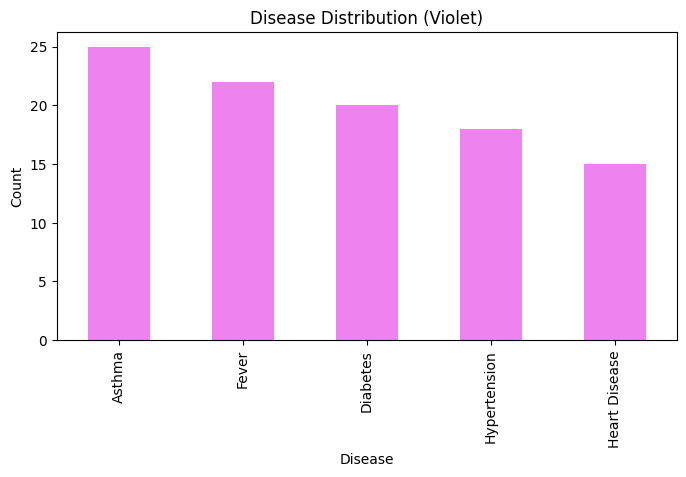

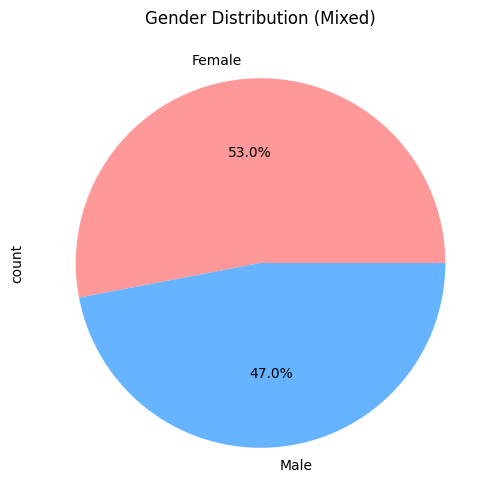

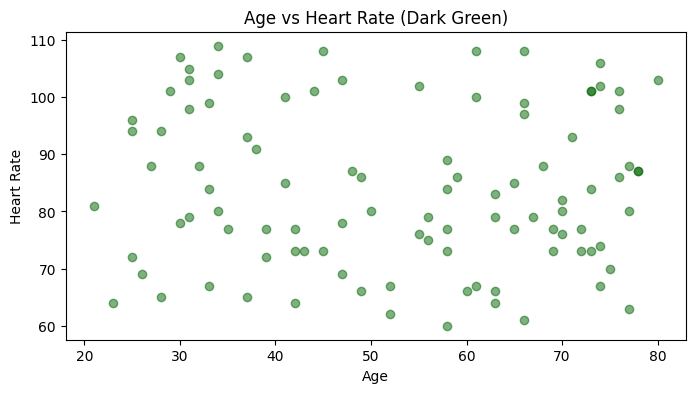

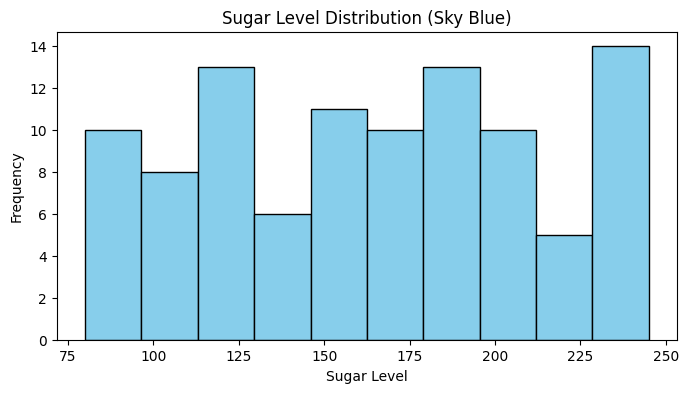

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
df['Disease'].value_counts().plot(kind='bar', color='violet')
plt.title('Disease Distribution (Violet)')
plt.xlabel('Disease')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(6, 6))
colors = ['#ff9999','#66b3ff']
df['Gender'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=colors)
plt.title('Gender Distribution (Mixed)')
plt.show()

plt.figure(figsize=(8, 4))
plt.scatter(df['Age'], df['Heart_Rate'], color='darkgreen', alpha=0.5)
plt.title('Age vs Heart Rate (Dark Green)')
plt.xlabel('Age')
plt.ylabel('Heart Rate')
plt.show()

plt.figure(figsize=(8, 4))
n, bins, patches = plt.hist(df['Sugar_Level'], bins=10, color='skyblue', edgecolor='black')
plt.title('Sugar Level Distribution (Sky Blue)')
plt.xlabel('Sugar Level')
plt.ylabel('Frequency')
plt.show()